In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from pathlib import Path

sys.path.append(os.path.abspath('..'))

# importar funções úteis do módulo de preprocessing
from src.preprocessing import *
from src.feature_engineering import *
from src.train import *
from src.utils import *
from src.evaluate import *

In [2]:
# Carregar o arquivo Excel
file_path = r'C:\Users\erick\Documents\FIAP\TC\FASE5_DATATHON\Base_pede.xlsx'

# Carregar os dados de cada ano
df_2022 = pd.read_excel(file_path, sheet_name='PEDE2022')
df_2023 = pd.read_excel(file_path, sheet_name='PEDE2023')
df_2024 = pd.read_excel(file_path, sheet_name='PEDE2024')

# Padronizar colunas
df22 = padronizar_colunas(df_2022, column_mapping, year=2022, return_summary=False)
df23 = padronizar_colunas(df_2023, column_mapping, year=2023, return_summary=False)
df24 = padronizar_colunas(df_2024, column_mapping, year=2024, return_summary=False)

# Concatenar dataframes
df_concat = pd.concat([df22, df23, df24], ignore_index=True)

# Aplicar correção de idade e enforcer de schema
df_fix_idade = fix_idade(df_concat)
df_schema, schema_errors = enforce_schema(df_fix_idade, schema= EXPECTED_SCHEMA)

#Tratamento de missings
df_pede, missing_summary = handle_missing_values(
    df_schema,
    numeric_cols=NUMERIC_COLS,
    categorical_cols=CATEGORICAL_COLS,
    add_missing_flags=True
)

In [3]:
df_pede[df_pede["ANO_BASE"] == 2024].head()

,RA,FASE,TURMA,NOME,IDADE_ALUNO,ANO_INGRESSO,INSTITUICAO_ENSINO_ALUNO,PEDRA,INDE,CG,...,IDA_MISSING,IPP_MISSING,IPV_MISSING,NOTA_PORT_MISSING,NOTA_MAT_MISSING,NOTA_ING_MISSING,QTDE_AVAL_MISSING,PEDRA_MISSING,CF_MISSING,CT_MISSING
1874,RA-1275,ALFA,ALFA A - G0/G1,Aluno-1275,8,2024,Pública,Ametista,7.611367,NaN,...,0,0,0,0,0,0,0,0,1,1
1875,RA-1276,ALFA,ALFA A - G0/G1,Aluno-1276,8,2024,Pública,Topázio,8.002867,NaN,...,0,0,0,0,0,0,0,0,1,1
1876,RA-1277,ALFA,ALFA A - G0/G1,Aluno-1277,8,2024,Pública,Ametista,7.952200,NaN,...,0,0,0,0,0,0,0,0,1,1
1877,RA-868,ALFA,ALFA A - G0/G1,Aluno-868,8,2023,Pública,Ametista,7.156367,NaN,...,0,0,0,0,0,0,0,0,1,1
1878,RA-1278,ALFA,ALFA A - G0/G1,Aluno-1278,9,2024,Pública,Quartzo,5.444200,NaN,...,0,0,0,0,0,0,0,0,1,1


In [4]:
# Copia o dataframe original
df_fe = df_pede.copy()

# Aplica feature engineering
df_fe = bin_idade(df_fe)
df_fe = encode_pedra(df_fe)
df_fe = create_basic_features(df_fe)

# Cria DF do modelo
df_model = df_fe.copy()

In [5]:
df_model["INDE"].value_counts()

INDE
7.388267    186
6.323000      3
7.305000      3
7.591000      3
7.619000      3
           ... 
6.112000      1
8.068000      1
7.226000      1
7.419380      1
8.085300      1
Name: count, Length: 2708, dtype: int64

In [6]:
df_model["ALTO_INDE"].value_counts()

ALTO_INDE
1    2001
0    1029
Name: count, dtype: int64

In [7]:
#Divisão do modelo em treino e teste
model, X_test, y_test = train(df_model, test_year=2024)

In [8]:
metrics_df = evaluate_metrics(model, X_test, y_test)
report_df = classification_report_df(model, X_test, y_test)

metrics_df
report_df

,label,precision,recall,f1-score,support
0,0,0.706751,0.994065,0.826141,337.000000
1,1,0.997067,0.830281,0.906063,819.000000
2,accuracy,0.878028,0.878028,0.878028,0.878028
3,macro avg,0.851909,0.912173,0.866102,1156.000000
4,weighted avg,0.912434,0.878028,0.882764,1156.000000


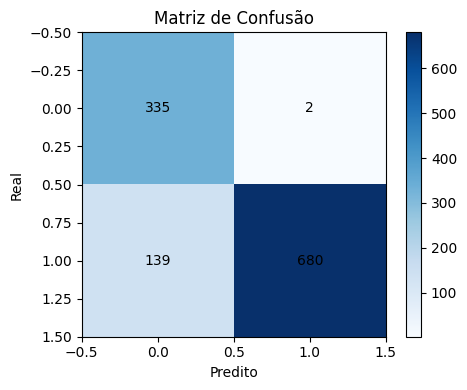

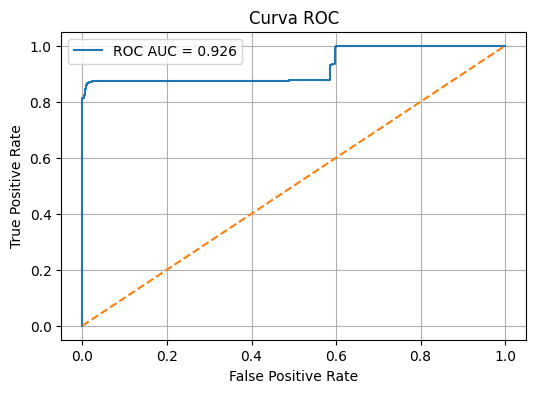

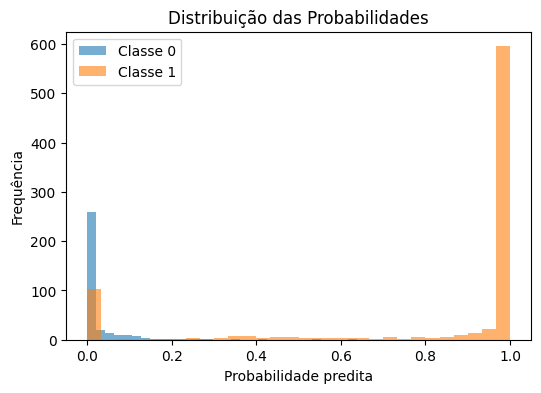

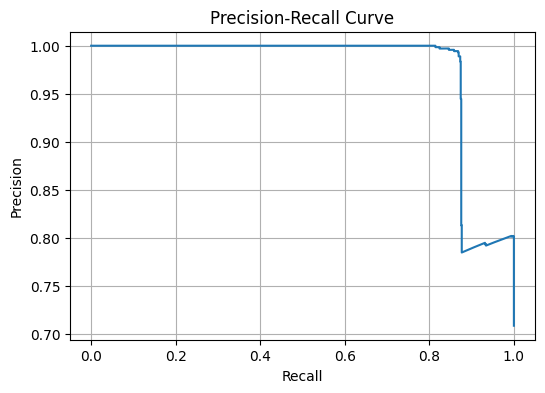

In [9]:
plot_confusion_matrix(model, X_test, y_test)
plot_roc_curve(model, X_test, y_test)
plot_proba_distribution(model, X_test, y_test)
plot_precision_recall_curve(model, X_test, y_test)

In [10]:
MODEL_DIR = Path("app/model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "model_v1.joblib"

#save_model(model, "app/model//model_v1.joblib")